***Model training and evaluation***

This notebook trains the NCF model adter splitting "interactions.csv" into train and test.

It also evalueates on the test set as well as calculating the Hit Rate @ 10 + NDCG scores

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd


interactions = pd.read_csv('data_processed/interactions.csv')

train, test = train_test_split(interactions, test_size=0.2, random_state=42, shuffle=True)

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"Train purchased distribution:\n{train['purchased'].value_counts()}")
print(f"Test purchased distribution:\n{test['purchased'].value_counts()}")

Train size: 1927728
Test size: 481932
Train purchased distribution:
purchased
0    1542195
1     385533
Name: count, dtype: int64
Test purchased distribution:
purchased
0    385533
1     96399
Name: count, dtype: int64


In [2]:
print('ratio train:', train['purchased'].value_counts()[0]/train['purchased'].value_counts()[1])
print('ratio test:', test['purchased'].value_counts()[0]/test['purchased'].value_counts()[1])

ratio train: 4.000163410136097
ratio test: 3.99934646624965


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
class RetailDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.items = torch.tensor(df['item_id'].values, dtype=torch.long)
        self.clusters = torch.tensor(df['cluster_id'].values, dtype=torch.long)
        self.purchased = torch.tensor(df['purchased'].values, dtype=torch.float)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.clusters[idx], self.purchased[idx]

In [6]:
train_dataset = RetailDataset(train)
test_dataset = RetailDataset(test)

len(train_dataset), len(test_dataset)

(1927728, 481932)

In [7]:
train_loader = DataLoader(
    train_dataset,           # which dataset?
    batch_size=256, # how many samples per batch? (hint: 256 is standard)
    shuffle=True    # should we shuffle training data? what about test data?
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False  
)

In [8]:
import os
from model import NCF
num_users = interactions['user_id'].nunique()
num_items = interactions['item_id'].nunique()
num_clusters = interactions['cluster_id'].nunique()

model = NCF(
    num_users=num_users,
    num_items=num_items,
    num_clusters=num_clusters
).to(device)

is_pretrained = False
if os.path.exists('model_weights/ncf_model.pth'):
    is_pretrained = True
    model.load_state_dict(torch.load('model_weights/ncf_model.pth', map_location=device))
    print("Loaded existing model weights from model_weights/ncf_model.pth")

print(model)

NCF(
  (user_embedding): Embedding(5878, 64)
  (item_embedding): Embedding(4631, 64)
  (cluster_embedding): Embedding(4, 8)
  (fc1): Linear(in_features=136, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)


In [9]:
criterion = nn.BCELoss()  # what loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # what learning rate

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for user, item, cluster, purchased in loader:
        # Move to device
        user = user.to(device)
        item = item.to(device)
        cluster = cluster.to(device)
        purchased = purchased.to(device)
        
        # 1. Zero the gradients
        optimizer.zero_grad()
        
        # 2. Forward pass — get predictions
        predictions = model(user, item, cluster).squeeze() 
        
        # 3. Calculate loss
        loss = criterion(predictions,purchased)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for user, item, cluster, purchased in loader:
            # Move to device
            user = user.to(device)
            item = item.to(device)
            cluster = cluster.to(device)
            purchased = purchased.to(device)

            # Forward pass
            predictions = model(user, item, cluster).squeeze()
            
            # Calculate loss
            loss = criterion(predictions,purchased)
            
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [12]:
if not is_pretrained:
    torch.manual_seed(42)  # for reproducibility

    NUM_EPOCHS = 100
    train_losses = []
    test_losses = []

    best_test_loss = float('inf')
    patience = 5
    patience_counter = 0
    best_model_weights = None
    best_epoch = -1


    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=20,  # try 5
        gamma=0.5       # try 0.5
    )


    for epoch in range(NUM_EPOCHS):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)  # call train_epoch
        test_loss = evaluate(model, test_loader, criterion, device)   # call evaluate
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

        # Early stopping logic
        if test_loss < best_test_loss:
            # test loss improved — what should you do here?
            best_test_loss = test_loss
            patience_counter = 0
            best_model_weights = model.state_dict()  # save best weights
            best_epoch = epoch + 1
        else:
            # test loss did not improve — what should you do here?
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_weights)  # restore best weights
                break
        scheduler.step()  # update learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"... | LR: {current_lr:.6f}")    

    torch.save(model.state_dict(), 'model_weights/ncf_model.pth')    
    

Epoch 1/100 | Train Loss: 0.4136 | Test Loss: 0.3991
... | LR: 0.001000
Epoch 2/100 | Train Loss: 0.3924 | Test Loss: 0.3964
... | LR: 0.001000
Epoch 3/100 | Train Loss: 0.3883 | Test Loss: 0.3939
... | LR: 0.001000
Epoch 4/100 | Train Loss: 0.3853 | Test Loss: 0.3903
... | LR: 0.001000
Epoch 5/100 | Train Loss: 0.3830 | Test Loss: 0.3894
... | LR: 0.001000
Epoch 6/100 | Train Loss: 0.3805 | Test Loss: 0.3878
... | LR: 0.001000
Epoch 7/100 | Train Loss: 0.3776 | Test Loss: 0.3874
... | LR: 0.001000
Epoch 8/100 | Train Loss: 0.3739 | Test Loss: 0.3837
... | LR: 0.001000
Epoch 9/100 | Train Loss: 0.3698 | Test Loss: 0.3814
... | LR: 0.001000
Epoch 10/100 | Train Loss: 0.3656 | Test Loss: 0.3794
... | LR: 0.001000
Epoch 11/100 | Train Loss: 0.3615 | Test Loss: 0.3786
... | LR: 0.001000
Epoch 12/100 | Train Loss: 0.3576 | Test Loss: 0.3766
... | LR: 0.001000
Epoch 13/100 | Train Loss: 0.3536 | Test Loss: 0.3745
... | LR: 0.001000
Epoch 14/100 | Train Loss: 0.3496 | Test Loss: 0.3720
... | 

In [15]:
print(best_epoch)
print(len(train_losses), len(test_losses))

28
33 33


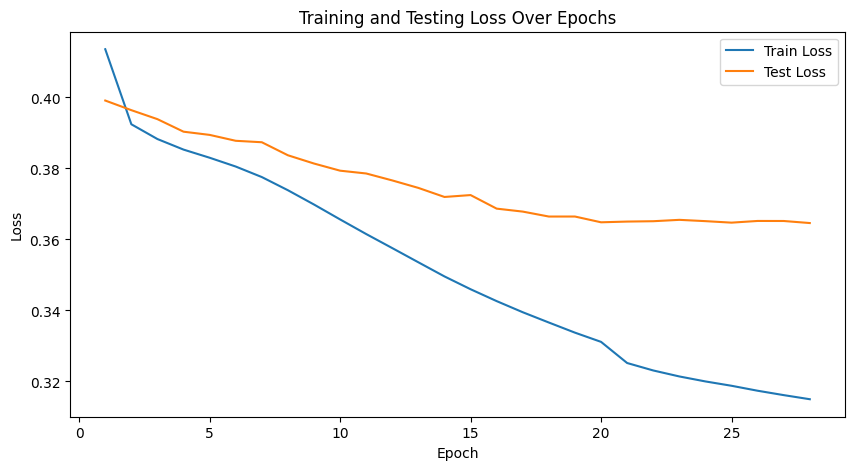

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, best_epoch + 1), train_losses[:best_epoch], label='Train Loss')
plt.plot(range(1, best_epoch + 1), test_losses[:best_epoch], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.legend()
plt.savefig('plots/train+test_losses.png')  # Save the plot as an image file
plt.show()

In [17]:
# All items a user bought in TRAINING set
train_user_items = train.groupby('user_id')['item_id'].apply(set).to_dict()

# All items a user bought in TEST set  
test_user_items = test.groupby('user_id')['item_id'].apply(set).to_dict()

In [18]:
import torch

def get_user_inputs(user_id, num_items, interactions, device):
    """Prepares and returns the user, item, and cluster tensors on the correct device."""
    user_tensor = torch.tensor([user_id] * num_items, dtype=torch.long).to(device)
    item_tensor = torch.tensor(range(num_items), dtype=torch.long).to(device)
    
    # Extract cluster ID (safely handles the single row extraction)
    cluster_id = interactions[interactions["user_id"] == user_id].iloc[[0]]['cluster_id'].values[0]
    cluster_tensor = torch.tensor([cluster_id] * num_items, dtype=torch.long).to(device)
    
    return user_tensor, item_tensor, cluster_tensor


def evaluate_user_hits(user_id, num_items, interactions, train_user_items, test_user_items, model, device, top_k=10):
    """Runs prediction for a single user and checks if any test items are in the top-K."""
    # 1. Get tensors
    user_tensor, item_tensor, cluster_tensor = get_user_inputs(user_id, num_items, interactions, device)
    
    # 2. Model Inference
    predictions = model(user_tensor, item_tensor, cluster_tensor).squeeze()

    # 3. Mask known train items
    known_items = list(train_user_items.get(user_id, set()))
    predictions[known_items] = float('-inf')

    # 4. Get Top-K recommendations
    _, idx = torch.topk(predictions, top_k)

    # 5. Evaluate against test set
    test_set = test_user_items.get(user_id, set())
    if not test_set:  # Edge case: if test set is empty, it's automatically 0 hits
        return 0, None
        
    set_tensor = torch.tensor(list(test_set), dtype=idx.dtype).to(device) # Moved to device to match idx
    matches = torch.isin(idx, set_tensor)
    
    return 1 if matches.sum().item() > 0 else 0, idx


def calculate_hit_rate(num_users, num_items, interactions, train_user_items, test_user_items, model, device, top_k=10):
    """Orchestrates the evaluation loop over all users and prints the final Hit Rate."""
    hits = 0
    
    with torch.no_grad():
        for user_id in range(num_users):
            hit, _ = evaluate_user_hits(
                user_id, num_items, interactions, 
                train_user_items, test_user_items, 
                model, device, top_k
            )
            hits += hit
            
            
    hit_rate = hits / num_users
    print(f'Hit rate @{top_k}: {hit_rate:.4f}')
    return hit_rate



In [19]:
def calculate_NDCG(num_users, num_items, interactions, train_user_items, test_user_items, model, device, top_k=10):
    total_sum = 0
    with torch.no_grad():
        for user_id in range(num_users):
            sum = 0
            _, idx = evaluate_user_hits(
                user_id, num_items, interactions, 
                train_user_items, test_user_items, 
                model, device, top_k
            )
            if idx is None:
                continue 
            for i in range(top_k):
                if idx[i].item() in test_user_items.get(user_id, set()):
                    sum += 1 / torch.log2(torch.tensor(i + 2, dtype=torch.float))
            total_sum += sum

    print(f'NDCG @{top_k}: {total_sum / num_users:.4f}')
    return total_sum / num_users
        

In [20]:
# hit_rate = calculate_hit_rate(num_users, num_items, interactions, train_user_items, test_user_items, model, device)
hit_rate = calculate_hit_rate(num_users, num_items, interactions, train_user_items, test_user_items, model, device)
ndcg = calculate_NDCG(num_users, num_items, interactions, train_user_items, test_user_items, model, device)
  

Hit rate @10: 0.3704
NDCG @10: 0.3103
